In [1]:
import json
import pandas as pd
from openai import OpenAI
import config

# OpenRouter Connection
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=config.OPENROUTER_API_KEY
)

print("Connection established.")

Connection established.


In [ ]:
with open('midterm-1.json', 'r', encoding='utf-8') as f:
    questions = json.load(f)

df = pd.DataFrame(questions)
display(df.head())

,id,topic,type,question,options,correct_answer,difficulty
0,1,Machine Learning for Security,MCQ,Which of the following would be the most disti...,"A) File size, B) Icon used, C) Imported kernel...",C,medium
1,2,Machine Learning for Security,MCQ,Which of the following is a dynamic analysis f...,"A) Number of sections, B) Registry snapshot di...",B,easy
2,3,Machine Learning for Security,MCQ,How should the labels be defined to detect thi...,"A) Low / Medium / High risk, B) Benign / Malwa...",B,easy
3,4,Machine Learning for Security,MCQ,If the model misses a ransomware variant it ha...,"A) Overfitting, B) Concept drift / unseen fami...",B,medium
4,5,Machine Learning for Security,TF,The high accuracy (>97%) reported in KDD-Cup-9...,True / False,False,medium


In [3]:
# Clear previous results for fresh start with Midterm 2
if 'all_model_results' in dir():
    all_model_results = {}
if 'rag_model_results' in dir():
    rag_model_results = {}
print("✅ Previous results cleared. Ready for Midterm 2!")


✅ Previous results cleared. Ready for Midterm 2!


In [92]:
# ============================================
# GLOBAL MODEL CONFIGURATION
# ============================================

# Define models here. Run this cell to update the lists.
# You do NOT need to run the testing cells below to update these lists.

# Models for Standard (Non-RAG) Testing
MODELS_TO_TEST = [
    "deepseek/deepseek-r1-0528",
    "meta-llama/llama-3.1-8b-instruct",
    "google/gemini-2.0-flash-lite-001",
    "nvidia/nemotron-nano-9b-v2",
    "openai/gpt-oss-20b"
]

# Models for RAG Testing
RAG_MODELS_TO_TEST = [
    "deepseek/deepseek-r1-0528",
    "meta-llama/llama-3.1-8b-instruct",
    "google/gemini-2.0-flash-lite-001",
    "nvidia/nemotron-nano-9b-v2",
    "openai/gpt-oss-20b"
]

print(f"Model Configuration Loaded:")
print(f"  Standard Models: {len(MODELS_TO_TEST)}")
print(f"  RAG Models:      {len(RAG_MODELS_TO_TEST)}")


Model Configuration Loaded:
  Standard Models: 5
  RAG Models:      5


In [ ]:
import time
import pandas as pd

if 'MODELS_TO_TEST' not in dir():
    print("⚠️ MODELS_TO_TEST not defined. Please run the configuration cell above.")
else:
    print(f"\nSTARTING AUTOMATED TESTING FOR {len(MODELS_TO_TEST)} MODELS\n")

    for i, model_name in enumerate(MODELS_TO_TEST):
        CURRENT_MODEL = model_name
        print(f"\n{'='*70}")
        print(f"Testing Model {i+1}/{len(MODELS_TO_TEST)}: {CURRENT_MODEL}")
        print('='*70)
        
        # Check if already tested
        if 'all_model_results' in dir() and CURRENT_MODEL in all_model_results:
            print(f"✓ {CURRENT_MODEL} already tested. Skipping...")
            continue
        
        # --- TEST LOGIC START ---
        print(f"Testing model: {CURRENT_MODEL}")
        print(f"Total questions: {len(questions)}")
        print("="*70)
        print(f"{'Q#':<4} {'Type':<5} {'Correct':<10} {'Model Answer':<20} {'Status'}")
        print("-"*70)

        results = []
        correct_count = 0

        for q in questions:
            system_msg = "You are a student. Answer only with the option letter (e.g., A) for MCQ, or True/False for TF questions. Do not explain."
            user_msg = f"Question Type: {q['type']}\nQuestion: {q['question']}\nOptions: {q['options']}\nAnswer:"
            
            try:
                completion = client.chat.completions.create(
                    model=CURRENT_MODEL,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg},
                    ]
                )
                answer = completion.choices[0].message.content.strip()
            except Exception as e:
                answer = "ERROR"
                print(f"{q['id']:<4} {q['type']:<5} {q['correct_answer']:<10} {'ERROR':<20} ❌ {str(e)[:30]}")
                results.append({
                    "id": q['id'], "topic": q['topic'], "type": q['type'],
                    "question": q['question'], "correct_answer": q['correct_answer'],
                    "model_answer": f"Error: {e}"
                })
                time.sleep(2)
                continue
            
            # Check if correct
            is_correct = str(answer).strip().upper() == str(q['correct_answer']).strip().upper()
            status = "✅" if is_correct else "❌"
            if is_correct:
                correct_count += 1
            
            # Show output
            print(f"{q['id']:<4} {q['type']:<5} {q['correct_answer']:<10} {answer:<20} {status}")
            
            results.append({
                "id": q['id'],
                "topic": q['topic'],
                "type": q['type'],
                "question": q['question'],
                "correct_answer": q['correct_answer'],
                "model_answer": answer
            })
            
            time.sleep(1)

        # Store results
        all_model_results[CURRENT_MODEL] = pd.DataFrame(results)

        print("-" * 70)
        print(f"\n✅ Completed: {CURRENT_MODEL}")
        print(f"📊 Score: {correct_count}/{len(questions)} correct ({correct_count/len(questions)*100:.1f}%)")
        print(f"📝 Total models tested so far: {len(all_model_results)}")
        # --- TEST LOGIC END ---


Testing model: openai/gpt-oss-20b
Total questions: 40
Q#   Type  Correct    Model Answer         Status
----------------------------------------------------------------------
1    MCQ   C          C                    ✅
2    MCQ   B          B                    ✅
3    MCQ   B          B                    ✅
4    MCQ   B          B                    ✅
5    TF    False      False                ✅
6    TF    True       True                 ✅
7    TF    False      False                ✅
8    TF    False      False                ✅
9    TF    False      False                ✅
10   MCQ   B          B                    ✅
11   MCQ   B          B                    ✅
12   MCQ   C          C                    ✅
13   MCQ   C          C                    ✅
14   MCQ   C          C                    ✅
15   TF    False      False                ✅
16   TF    False      False                ✅
17   TF    False      False                ✅
18   TF    True       True                 ✅
19   TF    Fals

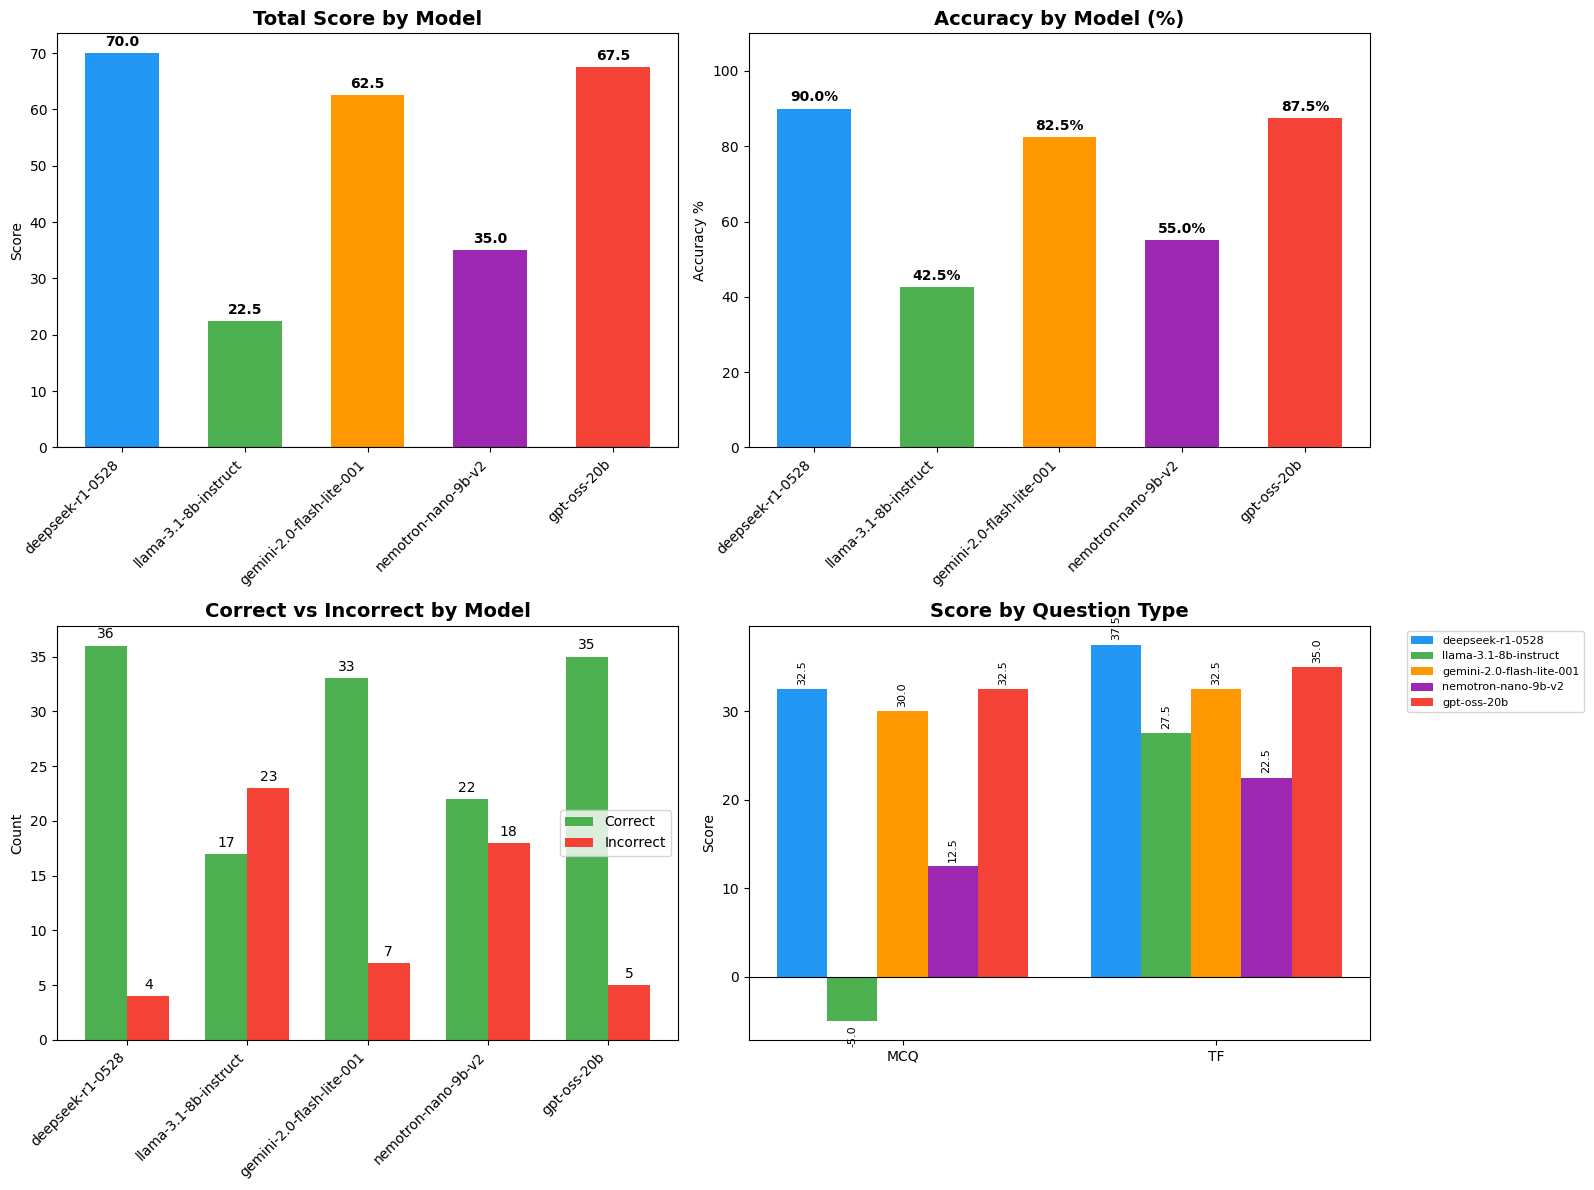

\n================================================================================
MODEL COMPARISON SUMMARY
Model                                    Score    Correct  Incorrect   Accuracy
--------------------------------------------------------------------------------
deepseek-r1-0528                          70.0         36          4      90.0%
llama-3.1-8b-instruct                     22.5         17         23      42.5%
gemini-2.0-flash-lite-001                 62.5         33          7      82.5%
nemotron-nano-9b-v2                       35.0         22         18      55.0%
gpt-oss-20b                               67.5         35          5      87.5%


In [89]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scoring Parameters
CORRECT_PTS = 2
INCORRECT_PTS = -0.5

def calc_score(row):
    return CORRECT_PTS if str(row['model_answer']).strip().upper() == str(row['correct_answer']).strip().upper() else INCORRECT_PTS

if 'all_model_results' not in dir() or len(all_model_results) == 0:
    print("No model results to analyze! Run model tests first.")
else:
    # Prepare data for plotting
    model_stats = {}
    for model, df in all_model_results.items():
        df['score'] = df.apply(calc_score, axis=1)
        df['is_correct'] = df['score'] == CORRECT_PTS
        
        # Shorten model name for display
        short_name = model.split('/')[1].split(':')[0] if '/' in model else model
        
        # Calculate stats by type if available
        stats_by_type = df.groupby('type')['score'].sum() if 'type' in df.columns else pd.Series()
        
        model_stats[short_name] = {
            'total_score': df['score'].sum(),
            'accuracy': df['is_correct'].sum() / len(df) * 100,
            'correct': df['is_correct'].sum(),
            'incorrect': (~df['is_correct']).sum(),
            'by_type': stats_by_type
        }
    
    models = list(model_stats.keys())
    n_models = len(models)
    
    # Colors
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'][:n_models]
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # 1. Total Score by Model
    scores = [model_stats[m]['total_score'] for m in models]
    x = np.arange(len(models))
    width = 0.6
    
    bars = axs[0, 0].bar(x, scores, width, color=colors)
    axs[0, 0].bar_label(bars, fmt='%.1f', padding=3, fontweight='bold')
    
    axs[0, 0].set_title('Total Score by Model', fontsize=14, fontweight='bold')
    axs[0, 0].set_ylabel('Score')
    axs[0, 0].set_xticks(x)
    axs[0, 0].set_xticklabels(models, rotation=45, ha='right')
    axs[0, 0].axhline(0, color='black', linewidth=0.8)
    
    # 2. Accuracy by Model
    accuracies = [model_stats[m]['accuracy'] for m in models]
    bars = axs[0, 1].bar(x, accuracies, width, color=colors)
    axs[0, 1].bar_label(bars, fmt='%.1f%%', padding=3, fontweight='bold')
    
    axs[0, 1].set_title('Accuracy by Model (%)', fontsize=14, fontweight='bold')
    axs[0, 1].set_ylabel('Accuracy %')
    axs[0, 1].set_xticks(x)
    axs[0, 1].set_xticklabels(models, rotation=45, ha='right')
    axs[0, 1].set_ylim(0, 110)
    
    # 3. Correct vs Incorrect by Model
    x = np.arange(len(models))
    width = 0.35
    correct_counts = [model_stats[m]['correct'] for m in models]
    incorrect_counts = [model_stats[m]['incorrect'] for m in models]
    
    bars1 = axs[1, 0].bar(x - width/2, correct_counts, width, label='Correct', color='#4CAF50')
    axs[1, 0].bar_label(bars1, fmt='%d', padding=3)
    
    bars2 = axs[1, 0].bar(x + width/2, incorrect_counts, width, label='Incorrect', color='#F44336')
    axs[1, 0].bar_label(bars2, fmt='%d', padding=3)
    
    axs[1, 0].set_title('Correct vs Incorrect by Model', fontsize=14, fontweight='bold')
    axs[1, 0].set_ylabel('Count')
    axs[1, 0].set_xticks(x)
    axs[1, 0].set_xticklabels(models, rotation=45, ha='right')
    axs[1, 0].legend()
    
    # 4. Performance by Question Type (grouped)
    if 'by_type' in model_stats[models[0]] and not model_stats[models[0]]['by_type'].empty:
        question_types = list(model_stats[models[0]]['by_type'].index)
        x = np.arange(len(question_types))
        width = 0.8 / n_models
        
        for i, model in enumerate(models):
            type_scores = [model_stats[model]['by_type'].loc[t] if t in model_stats[model]['by_type'] else 0 for t in question_types]
            offset = (i - n_models/2 + 0.5) * width
            bars = axs[1, 1].bar(x + offset, type_scores, width, label=model, color=colors[i])
            axs[1, 1].bar_label(bars, fmt='%.1f', padding=3, fontsize=8, rotation=90)
            
        axs[1, 1].set_title('Score by Question Type', fontsize=14, fontweight='bold')
        axs[1, 1].set_ylabel('Score')
        axs[1, 1].set_xticks(x)
        axs[1, 1].set_xticklabels(question_types)
        axs[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        axs[1, 1].axhline(0, color='black', linewidth=0.8)
    else:
        axs[1, 1].text(0.5, 0.5, "No Question Type Data", ha='center', va='center')

    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    print(f"{'Model':<35} {'Score':>10} {'Correct':>10} {'Incorrect':>10} {'Accuracy':>10}")
    print("-"*80)
    for model in models:
        s = model_stats[model]
        print(f"{model:<35} {s['total_score']:>10.1f} {s['correct']:>10} {s['incorrect']:>10} {s['accuracy']:>9.1f}%")
    print("="*80)


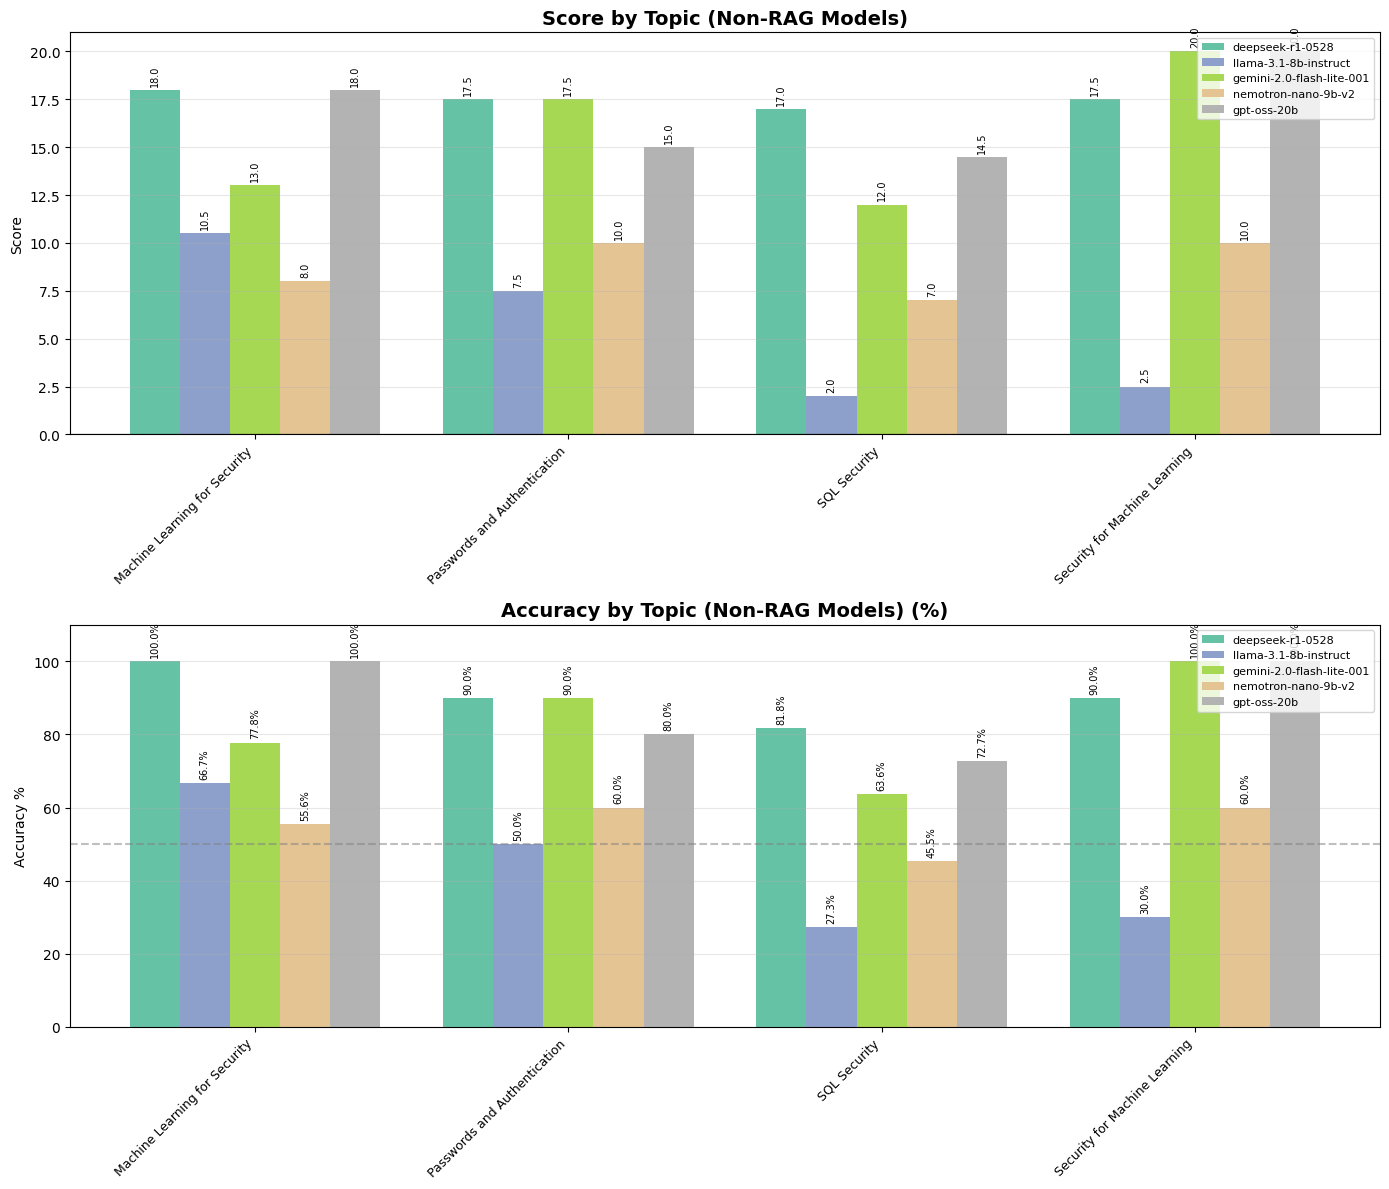

\n====================================================================================================
PERFORMANCE BY TOPIC - DETAILED SUMMARY (Non-RAG Models)
\n📊 deepseek-r1-0528
--------------------------------------------------------------------------------
Topic                                       Total    Correct     Accuracy      Score
--------------------------------------------------------------------------------
Machine Learning for Security                   9          9       100.0%       18.0
Passwords and Authentication                   10          9        90.0%       17.5
SQL Security                                   11          9        81.8%       17.0
Security for Machine Learning                  10          9        90.0%       17.5
\n  🏆 Best topic:  Machine Learning for Security (100.0%)
  ⚠️ Worst topic: SQL Security (81.8%)
\n📊 llama-3.1-8b-instruct
--------------------------------------------------------------------------------
Topic                       

In [79]:

# Scoring Parameters
CORRECT_PTS = 2
INCORRECT_PTS = -0.5

def calc_score(row):
    return CORRECT_PTS if str(row['model_answer']).strip().upper() == str(row['correct_answer']).strip().upper() else INCORRECT_PTS

# Only use non-RAG results
results_to_analyze = {}

if 'all_model_results' in dir() and all_model_results:
    for model, df in all_model_results.items():
        short_name = model.split('/')[1].split(':')[0] if '/' in model else model
        results_to_analyze[short_name] = df.copy()

# NOTE: RAG results excluded from this visualization
# To include RAG results, uncomment the following:
# if 'rag_model_results' in dir() and rag_model_results:
#     for model, df in rag_model_results.items():
#         short_name = model.split('/')[1].split(':')[0] if '/' in model else model
#         results_to_analyze[f"{short_name} (RAG)"] = df.copy()

if len(results_to_analyze) == 0:
    print("No results to analyze! Run model tests first.")
else:
    # Calculate topic stats for each model
    topic_stats = {}
    all_topics = set()
    
    for model_name, df in results_to_analyze.items():
        df['score'] = df.apply(calc_score, axis=1)
        df['is_correct'] = df['score'] == CORRECT_PTS
        
        stats = df.groupby('topic').agg(
            total=('id', 'count'),
            correct=('is_correct', 'sum'),
            score=('score', 'sum')
        )
        stats['accuracy'] = stats['correct'] / stats['total'] * 100
        topic_stats[model_name] = stats
        all_topics.update(stats.index.tolist())
    
    topics = sorted(list(all_topics))
    models = list(topic_stats.keys())
    n_models = len(models)
    n_topics = len(topics)
    
    # Create color palette
    colors = plt.cm.Set2(np.linspace(0, 1, n_models))
    
    # Create figures
    fig, axs = plt.subplots(2, 1, figsize=(14, 12))
    plt.subplots_adjust(hspace=0.4)
    
    # 1. Score by Topic (grouped bar chart)
    x = np.arange(n_topics)
    width = 0.8 / n_models
    
    for i, model in enumerate(models):
        scores = [topic_stats[model].loc[t, 'score'] if t in topic_stats[model].index else 0 for t in topics]
        offset = (i - n_models/2 + 0.5) * width
        bars = axs[0].bar(x + offset, scores, width, label=model, color=colors[i])
        axs[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=7, rotation=90)
    
    axs[0].set_title('Score by Topic (Non-RAG Models)', fontsize=14, fontweight='bold')
    axs[0].set_ylabel('Score')
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(topics, rotation=45, ha='right', fontsize=9)
    axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axs[0].axhline(0, color='black', linewidth=0.8)
    axs[0].grid(axis='y', alpha=0.3)
    
    # 2. Accuracy by Topic (grouped bar chart)
    for i, model in enumerate(models):
        accuracies = [topic_stats[model].loc[t, 'accuracy'] if t in topic_stats[model].index else 0 for t in topics]
        offset = (i - n_models/2 + 0.5) * width
        bars = axs[1].bar(x + offset, accuracies, width, label=model, color=colors[i])
        axs[1].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=7, rotation=90)
    
    axs[1].set_title('Accuracy by Topic (Non-RAG Models) (%)', fontsize=14, fontweight='bold')
    axs[1].set_ylabel('Accuracy %')
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(topics, rotation=45, ha='right', fontsize=9)
    axs[1].legend(loc='upper right', fontsize=8)
    axs[1].set_ylim(0, 110)
    axs[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
    axs[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary for each model
    print("\\n" + "="*100)
    print("PERFORMANCE BY TOPIC - DETAILED SUMMARY (Non-RAG Models)")
    print("="*100)
    
    for model in models:
        print(f"\\n📊 {model}")
        print("-"*80)
        print(f"{'Topic':<40} {'Total':>8} {'Correct':>10} {'Accuracy':>12} {'Score':>10}")
        print("-"*80)
        
        stats = topic_stats[model]
        for topic in topics:
            if topic in stats.index:
                row = stats.loc[topic]
                print(f"{topic:<40} {int(row['total']):>8} {int(row['correct']):>10} {row['accuracy']:>11.1f}% {row['score']:>10.1f}")
        
        # Identify best/worst topics
        best_topic = stats['accuracy'].idxmax()
        worst_topic = stats['accuracy'].idxmin()
        print(f"\\n  🏆 Best topic:  {best_topic} ({stats.loc[best_topic, 'accuracy']:.1f}%)")
        print(f"  ⚠️ Worst topic: {worst_topic} ({stats.loc[worst_topic, 'accuracy']:.1f}%)")
    
    print("\\n" + "="*100)


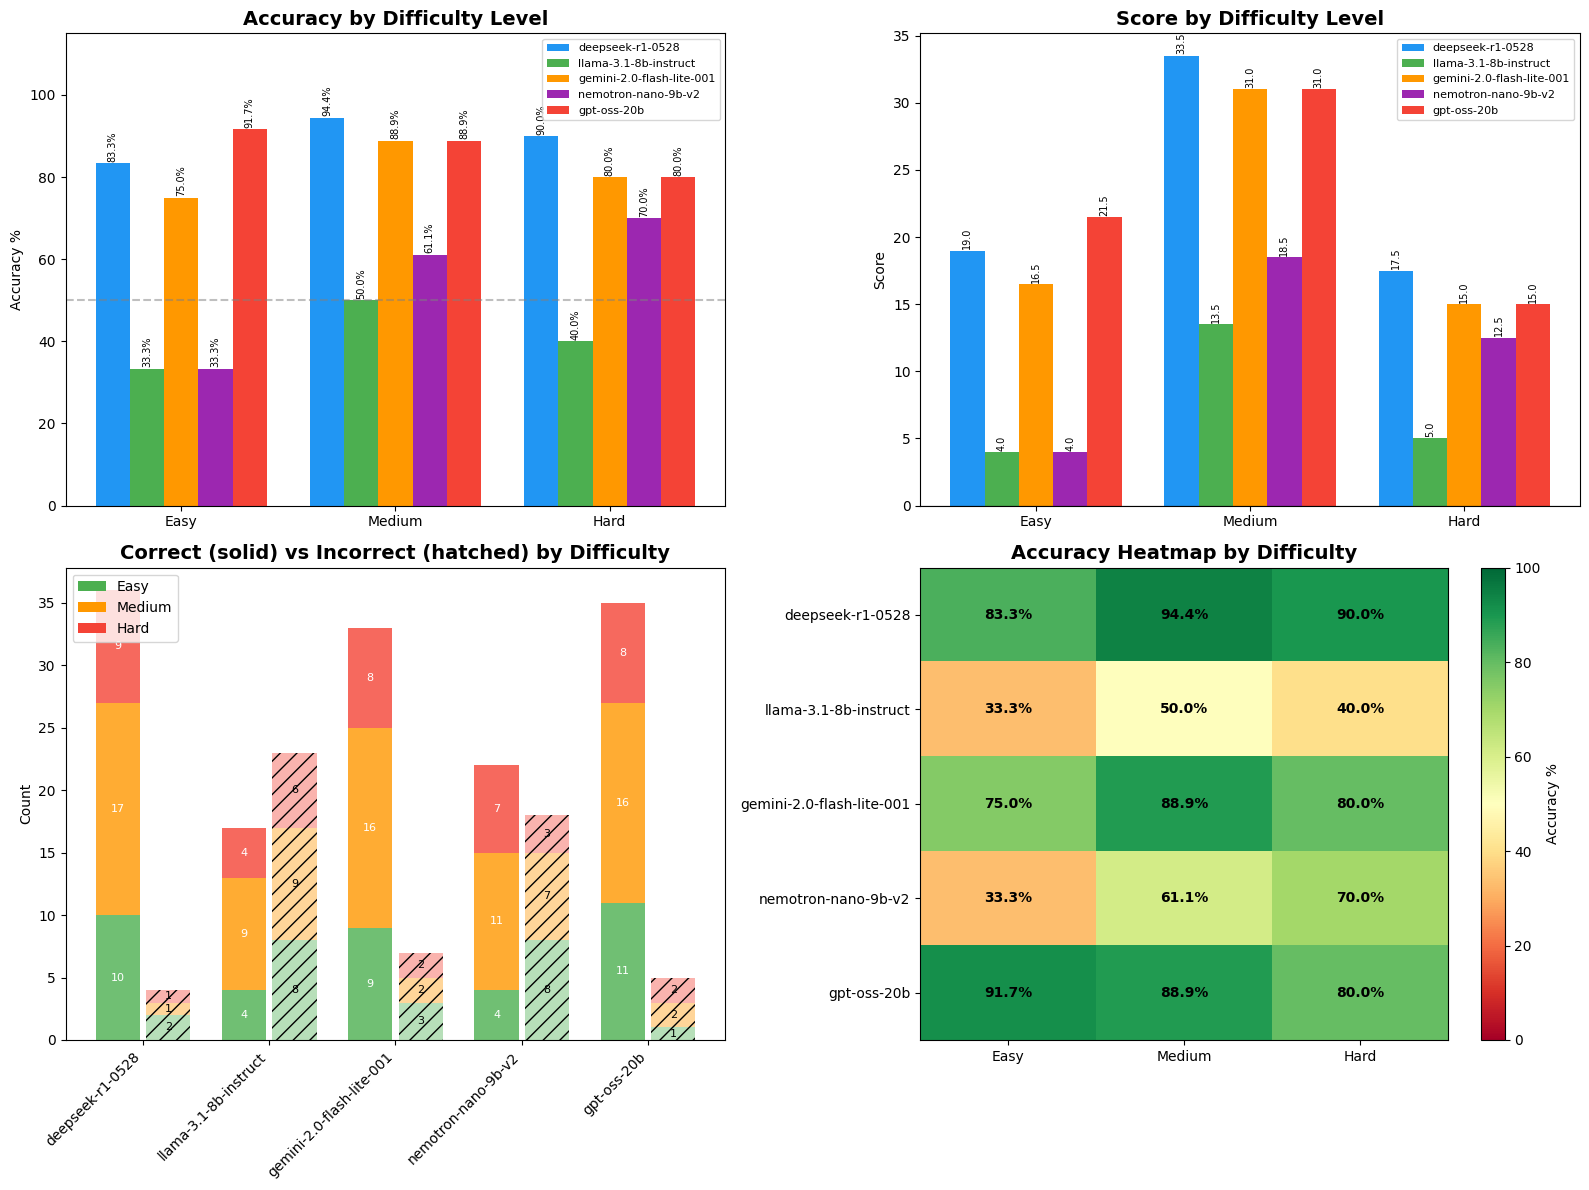

\n==========================================================================================
PERFORMANCE BY DIFFICULTY LEVEL
\n📊 deepseek-r1-0528
------------------------------------------------------------
Difficulty      Total    Correct     Accuracy      Score
------------------------------------------------------------
Easy               12         10        83.3%       19.0
Medium             18         17        94.4%       33.5
Hard               10          9        90.0%       17.5
\n🏆 Best performance: MEDIUM questions
\n📊 llama-3.1-8b-instruct
------------------------------------------------------------
Difficulty      Total    Correct     Accuracy      Score
------------------------------------------------------------
Easy               12          4        33.3%        4.0
Medium             18          9        50.0%       13.5
Hard               10          4        40.0%        5.0
\n🏆 Best performance: MEDIUM questions
\n📊 gemini-2.0-flash-lite-001
--------------------

In [80]:
if len(all_model_results) == 0:
    print("No models tested yet! Run the model test cell first.")
else:
    # Scoring Parameters
    CORRECT_PTS = 2
    INCORRECT_PTS = -0.5
    
    def calculate_score(row):
        model_ans = str(row['model_answer']).strip().upper()
        correct_ans = str(row['correct_answer']).strip().upper()
        return CORRECT_PTS if model_ans == correct_ans else INCORRECT_PTS
    
    # Need to reload questions to get difficulty levels
    import json
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    try:
        with open('midterm-2.json', 'r', encoding='utf-8') as f:
            questions_with_diff = json.load(f)
    except:
        try:
            with open('/Users/baris/Jupyter project/midterm-2.json', 'r', encoding='utf-8') as f:
                questions_with_diff = json.load(f)
        except:
            print("Could not load midterm-2.json for difficulty data.")
            questions_with_diff = []

    if questions_with_diff:
        # Create difficulty lookup
        diff_lookup = {q['id']: q.get('difficulty', 'medium') for q in questions_with_diff}
        
        # Calculate stats by difficulty for each model
        difficulty_stats = {}
        difficulty_order = ['easy', 'medium', 'hard']
        
        for model_name, df in all_model_results.items():
            # Add difficulty column
            df['difficulty'] = df['id'].map(diff_lookup)
            df['score'] = df.apply(calculate_score, axis=1)
            df['is_correct'] = df['score'] == CORRECT_PTS
            
            short_name = model_name.split('/')[1].split(':')[0] if '/' in model_name else model_name
            
            stats_by_diff = {}
            for diff in difficulty_order:
                subset = df[df['difficulty'] == diff]
                if len(subset) > 0:
                    stats_by_diff[diff] = {
                        'total': len(subset),
                        'correct': subset['is_correct'].sum(),
                        'accuracy': subset['is_correct'].sum() / len(subset) * 100,
                        'score': subset['score'].sum()
                    }
            difficulty_stats[short_name] = stats_by_diff
        
        # Create visualizations
        n_models = len(difficulty_stats)
        models = list(difficulty_stats.keys())
        colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'][:n_models]
        diff_colors = {'easy': '#4CAF50', 'medium': '#FF9800', 'hard': '#F44336'}
        
        fig, axs = plt.subplots(2, 2, figsize=(16, 12))
        plt.subplots_adjust(hspace=0.4, wspace=0.3)
        
        # 1. Accuracy by Difficulty Level (grouped by model)
        x = np.arange(len(difficulty_order))
        width = 0.8 / n_models
        for i, model in enumerate(models):
            accuracies = [difficulty_stats[model].get(d, {}).get('accuracy', 0) for d in difficulty_order]
            offset = (i - n_models/2 + 0.5) * width
            bars = axs[0, 0].bar(x + offset, accuracies, width, label=model, color=colors[i])
            axs[0, 0].bar_label(bars, fmt='%.1f%%', padding=1, fontsize=7, rotation=90)
        axs[0, 0].set_title('Accuracy by Difficulty Level', fontsize=14, fontweight='bold')
        axs[0, 0].set_ylabel('Accuracy %')
        axs[0, 0].set_xticks(x)
        axs[0, 0].set_xticklabels(['Easy', 'Medium', 'Hard'])
        axs[0, 0].set_ylim(0, 115)
        axs[0, 0].legend(loc='upper right', fontsize=8)
        axs[0, 0].axhline(50, color='gray', linestyle='--', alpha=0.5)
        
        # 2. Score by Difficulty Level (grouped by model)
        for i, model in enumerate(models):
            scores = [difficulty_stats[model].get(d, {}).get('score', 0) for d in difficulty_order]
            offset = (i - n_models/2 + 0.5) * width
            bars = axs[0, 1].bar(x + offset, scores, width, label=model, color=colors[i])
            axs[0, 1].bar_label(bars, fmt='%.1f', padding=1, fontsize=7, rotation=90)
        axs[0, 1].set_title('Score by Difficulty Level', fontsize=14, fontweight='bold')
        axs[0, 1].set_ylabel('Score')
        axs[0, 1].set_xticks(x)
        axs[0, 1].set_xticklabels(['Easy', 'Medium', 'Hard'])
        axs[0, 1].legend(loc='upper right', fontsize=8)
        axs[0, 1].axhline(0, color='black', linewidth=0.8)
        
        # 3. For each model: stacked bar showing correct/incorrect by difficulty
        x = np.arange(n_models)
        bottom_correct = np.zeros(n_models)
        bottom_incorrect = np.zeros(n_models)
        
        for diff in difficulty_order:
            correct_vals = [difficulty_stats[m].get(diff, {}).get('correct', 0) for m in models]
            total_vals = [difficulty_stats[m].get(diff, {}).get('total', 0) for m in models]
            incorrect_vals = [t - c for t, c in zip(total_vals, correct_vals)]
            
            bars1 = axs[1, 0].bar(x - 0.2, correct_vals, 0.35, bottom=bottom_correct, 
                          label=f'{diff.capitalize()} ✅' if diff == 'easy' else '', 
                          color=diff_colors[diff], alpha=0.8)
            axs[1, 0].bar_label(bars1, label_type='center', fmt='%d', fontsize=8, color='white')
            
            bars2 = axs[1, 0].bar(x + 0.2, incorrect_vals, 0.35, bottom=bottom_incorrect,
                          color=diff_colors[diff], alpha=0.4, hatch='//')
            axs[1, 0].bar_label(bars2, label_type='center', fmt='%d', fontsize=8)
            
            bottom_correct += correct_vals
            bottom_incorrect += incorrect_vals
        
        axs[1, 0].set_title('Correct (solid) vs Incorrect (hatched) by Difficulty', fontsize=14, fontweight='bold')
        axs[1, 0].set_ylabel('Count')
        axs[1, 0].set_xticks(x)
        axs[1, 0].set_xticklabels(models, rotation=45, ha='right')
        
        # Add legend for difficulty colors
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=diff_colors[d], label=d.capitalize()) for d in difficulty_order]
        axs[1, 0].legend(handles=legend_elements, loc='upper left')
        
        # 4. Heatmap: Model vs Difficulty accuracy
        heatmap_data = []
        for model in models:
            row = [difficulty_stats[model].get(d, {}).get('accuracy', 0) for d in difficulty_order]
            heatmap_data.append(row)
        heatmap_data = np.array(heatmap_data)
        
        im = axs[1, 1].imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
        axs[1, 1].set_xticks(np.arange(len(difficulty_order)))
        axs[1, 1].set_yticks(np.arange(n_models))
        axs[1, 1].set_xticklabels(['Easy', 'Medium', 'Hard'])
        axs[1, 1].set_yticklabels(models)
        axs[1, 1].set_title('Accuracy Heatmap by Difficulty', fontsize=14, fontweight='bold')
        
        # Add text annotations
        for i in range(n_models):
            for j in range(len(difficulty_order)):
                text = axs[1, 1].text(j, i, f'{heatmap_data[i, j]:.1f}%',
                                       ha='center', va='center', color='black', fontweight='bold')
        
        plt.colorbar(im, ax=axs[1, 1], label='Accuracy %')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed summary
        print("\\n" + "="*90)
        print("PERFORMANCE BY DIFFICULTY LEVEL")
        print("="*90)
        
        for model in models:
            print(f"\\n📊 {model}")
            print("-"*60)
            print(f"{'Difficulty':<12} {'Total':>8} {'Correct':>10} {'Accuracy':>12} {'Score':>10}")
            print("-"*60)
            for diff in difficulty_order:
                s = difficulty_stats[model].get(diff, {})
                if s:
                    print(f"{diff.capitalize():<12} {s['total']:>8} {s['correct']:>10} {s['accuracy']:>11.1f}% {s['score']:>10.1f}")
            
            # Find best performing difficulty
            best_diff = max(difficulty_order, key=lambda d: difficulty_stats[model].get(d, {}).get('accuracy', 0))
            print(f"\\n🏆 Best performance: {best_diff.upper()} questions")
        
        print("\\n" + "="*90)


In [1]:
# Install RAG dependencies (run this cell first)
%pip install langchain langchain-community langchain-text-splitters pypdf faiss-cpu sentence-transformers



[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
import os

# List of lecture PDFs
pdf_files = [
    "08-ML-for-Cybersecurity.pdf",
    "09-Security-for-ML.pdf",
    "10-Passwords-and-Authentication.pdf",
    "11-Database-Security.pdf"
]

print("Loading lecture PDFs...")
all_documents = []

for pdf_file in pdf_files:
    if os.path.exists(pdf_file):
        print(f"  Loading: {pdf_file}")
        loader = PyPDFLoader(pdf_file)
        documents = loader.load()
        all_documents.extend(documents)
        print(f"    Loaded {len(documents)} pages")
    else:
        print(f"  ⚠️ Not found: {pdf_file}")

print(f"\nTotal pages loaded: {len(all_documents)}")

# Split documents into chunks
print("\nSplitting into chunks...")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len
)
chunks = text_splitter.split_documents(all_documents)
print(f"Created {len(chunks)} chunks")

# Create embeddings and vector store
print("\nCreating embeddings (this may take a few minutes)...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(chunks, embeddings)
print("✅ Vector store created!")

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("✅ RAG system ready!")


Loading lecture PDFs...
  Loading: 08-ML-for-Cybersecurity.pdf
    Loaded 57 pages
  Loading: 09-Security-for-ML.pdf
    Loaded 49 pages
  Loading: 10-Passwords-and-Authentication.pdf
    Loaded 39 pages
  Loading: 11-Database-Security.pdf
    Loaded 42 pages

Total pages loaded: 187

Splitting into chunks...
Created 185 chunks

Creating embeddings (this may take a few minutes)...


/var/folders/5s/chzv716n4pn21jvj3h4t1vlr0000gn/T/ipykernel_35808/3563691067.py:42: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


✅ Vector store created!
✅ RAG system ready!


In [ ]:
import time
import pandas as pd

if 'RAG_MODELS_TO_TEST' not in dir():
    print("⚠️ RAG_MODELS_TO_TEST not defined. Please run the configuration cell above.")
else:
    print(f"\nSTARTING AUTOMATED RAG TESTING FOR {len(RAG_MODELS_TO_TEST)} MODELS\n")

    for i, model_name in enumerate(RAG_MODELS_TO_TEST):
        RAG_MODEL = model_name
        print(f"\n{'='*70}")
        print(f"Testing RAG Model {i+1}/{len(RAG_MODELS_TO_TEST)}: {RAG_MODEL}")
        print('='*70)
        
        # Check if already tested
        if 'rag_model_results' in dir() and RAG_MODEL in rag_model_results:
            print(f"✓ {RAG_MODEL} (RAG) already tested. Skipping...")
            continue
        
        # --- TEST LOGIC START ---
        print(f"Testing model WITH RAG: {RAG_MODEL}")
        print(f"Total questions: {len(questions)}")
        print("=" * 80)
        print(f"{'Q#':<4} {'Type':<5} {'Correct':<10} {'Model Answer':<20} {'Status':<6} {'Context Used'}")
        print("-" * 80)

        rag_results = []
        correct_count = 0

        for q in questions:
            # STEP 1: Retrieve relevant context from lecture PDFs
            try:
                query = f"{q['question']} {q['options']}"
                retrieved_docs = retriever.invoke(query)
                context = "\n\n".join([doc.page_content for doc in retrieved_docs])
            except Exception as e:
                print(f"Retrieval error: {e}")
                context = ""
            
            # STEP 2: Create RAG-enhanced prompt
            system_msg = """ONLY WRITE True, False, A, B, C, D. Do NOT write anything else. You are a student taking an exam. Use the provided lecture notes to answer the question.
Answer only with the option letter (e.g., A) for MCQ, or True/False for TF questions. Do not explain."""
            
            user_msg = f"""LECTURE NOTES:
{context}

QUESTION:
Question Type: {q['type']}
Question: {q['question']}
Options: {q['options']}

Answer:"""
            
            try:
                completion = client.chat.completions.create(
                    model=RAG_MODEL,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg},
                    ]
                )
                answer = completion.choices[0].message.content.strip()
            except Exception as e:
                answer = "ERROR"
                print(f"{q['id']:<4} {q['type']:<5} {q['correct_answer']:<10} {'ERROR':<20} ❌     {str(e)[:20]}")
                rag_results.append({
                    "id": q['id'], "topic": q['topic'], "type": q['type'],
                    "question": q['question'], "correct_answer": q['correct_answer'],
                    "model_answer": f"Error: {e}", "context_preview": context[:100]
                })
                time.sleep(2)
                continue
            
            # Check if correct
            is_correct = str(answer).strip().upper() == str(q['correct_answer']).strip().upper()
            status = "✅" if is_correct else "❌"
            if is_correct:
                correct_count += 1
            
            # Show context source
            context_src = retrieved_docs[0].metadata.get('source', 'unknown')[:25] if retrieved_docs else 'none'
            
            print(f"{q['id']:<4} {q['type']:<5} {q['correct_answer']:<10} {answer:<20} {status:<6} {context_src}")
            
            rag_results.append({
                "id": q['id'],
                "topic": q['topic'],
                "type": q['type'],
                "question": q['question'],
                "correct_answer": q['correct_answer'],
                "model_answer": answer,
                "context_preview": context[:200]
            })
            
            time.sleep(2)

        # Store results
        rag_model_results[RAG_MODEL] = pd.DataFrame(rag_results)

        print("-" * 80)
        print(f"\n✅ RAG Test Completed: {RAG_MODEL}")
        print(f"📊 Score: {correct_count}/{len(questions)} correct ({correct_count/len(questions)*100:.1f}%)")
        print(f"📝 Total RAG models tested: {len(rag_model_results)}")
        # --- TEST LOGIC END ---


Testing model WITH RAG: openai/gpt-oss-20b
Total questions: 40
Q#   Type  Correct    Model Answer         Status Context Used
--------------------------------------------------------------------------------
1    MCQ   C          C                    ✅      08-ML-for-Cybersecurity.p
2    MCQ   B          B                    ✅      08-ML-for-Cybersecurity.p
3    MCQ   B          B                    ✅      09-Security-for-ML.pdf
4    MCQ   B          B                    ✅      08-ML-for-Cybersecurity.p
5    TF    False      False                ✅      08-ML-for-Cybersecurity.p
6    TF    True       True                 ✅      08-ML-for-Cybersecurity.p
7    TF    False      False                ✅      08-ML-for-Cybersecurity.p
8    TF    False      False                ✅      08-ML-for-Cybersecurity.p
9    TF    False      False                ✅      08-ML-for-Cybersecurity.p
10   MCQ   B          B                    ✅      09-Security-for-ML.pdf
11   MCQ   B          B                

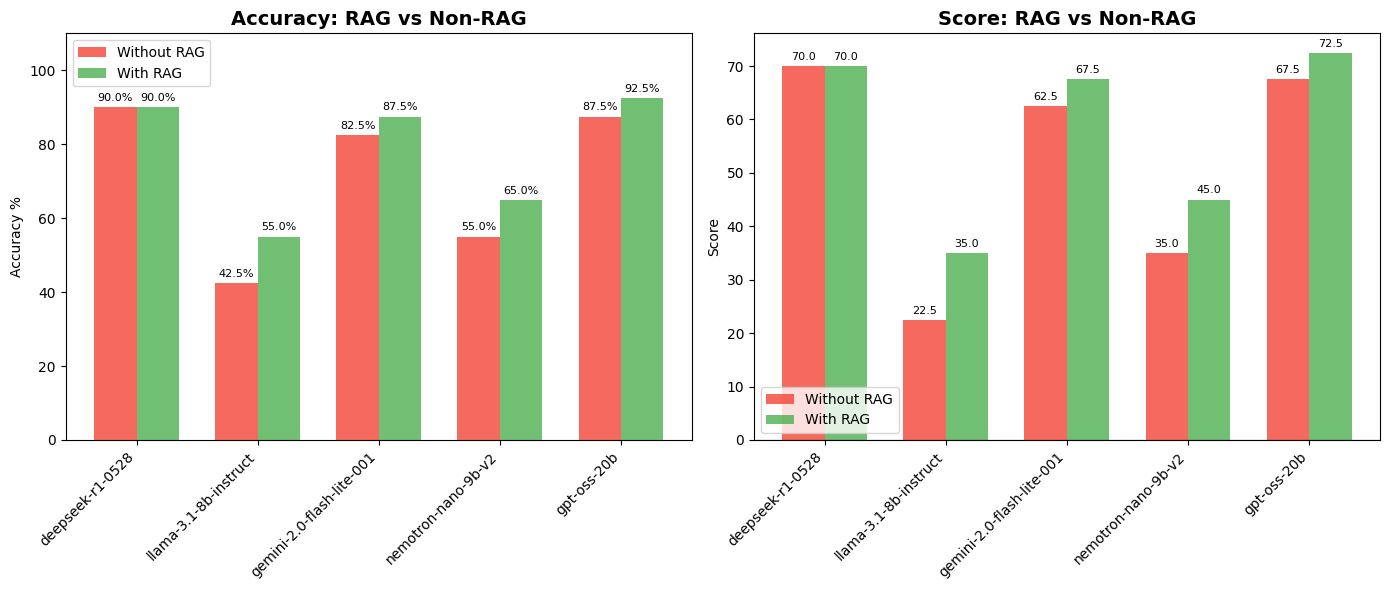

\n================================================================================
RAG vs NON-RAG COMPARISON
Model                          Type                 Score     Accuracy
--------------------------------------------------------------------------------
deepseek-r1-0528               With RAG              70.0        90.0%
deepseek-r1-0528               Without RAG           70.0        90.0%
gemini-2.0-flash-lite-001      With RAG              67.5        87.5%
gemini-2.0-flash-lite-001      Without RAG           62.5        82.5%
gpt-oss-20b                    With RAG              72.5        92.5%
gpt-oss-20b                    Without RAG           67.5        87.5%
llama-3.1-8b-instruct          With RAG              35.0        55.0%
llama-3.1-8b-instruct          Without RAG           22.5        42.5%
nemotron-nano-9b-v2            With RAG              45.0        65.0%
nemotron-nano-9b-v2            Without RAG           35.0        55.0%
\n📈 RAG IMPROVEMENT:
  ➡️ dee

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scoring
CORRECT_PTS = 2
INCORRECT_PTS = -0.5

def calc_score(row):
    return CORRECT_PTS if str(row['model_answer']).strip().upper() == str(row['correct_answer']).strip().upper() else INCORRECT_PTS

# Check if we have both RAG and non-RAG results to compare
if 'all_model_results' not in dir() or len(all_model_results) == 0:
    print("No non-RAG results to compare! Run basic model tests first.")
elif 'rag_model_results' not in dir() or len(rag_model_results) == 0:
    print("No RAG results to compare! Run RAG model tests first.")
else:
    comparison_data = []
    
    # Add non-RAG results
    for model, df in all_model_results.items():
        df['score'] = df.apply(calc_score, axis=1)
        short_name = model.split('/')[1].split(':')[0] if '/' in model else model
        comparison_data.append({
            'model': short_name,
            'type': 'Without RAG',
            'score': df['score'].sum(),
            'accuracy': (df['score'] == CORRECT_PTS).sum() / len(df) * 100
        })
    
    # Add RAG results
    for model, df in rag_model_results.items():
        df['score'] = df.apply(calc_score, axis=1)
        short_name = model.split('/')[1].split(':')[0] if '/' in model else model
        comparison_data.append({
            'model': short_name,
            'type': 'With RAG',
            'score': df['score'].sum(),
            'accuracy': (df['score'] == CORRECT_PTS).sum() / len(df) * 100
        })
    
    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)
        
        # Find models that have both RAG and non-RAG results
        models_with_both = set(comp_df[comp_df['type'] == 'Without RAG']['model']) & \
                           set(comp_df[comp_df['type'] == 'With RAG']['model'])
        
        fig, axs = plt.subplots(1, 2, figsize=(14, 6))
        
        # Plot all results
        models = comp_df['model'].unique()
        x = np.arange(len(models))
        width = 0.35
        
        no_rag = [comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'Without RAG')]['accuracy'].values[0] 
                  if len(comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'Without RAG')]) > 0 else 0 
                  for m in models]
        with_rag = [comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'With RAG')]['accuracy'].values[0] 
                    if len(comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'With RAG')]) > 0 else 0 
                    for m in models]
        
        bars1 = axs[0].bar(x - width/2, no_rag, width, label='Without RAG', color='#F44336', alpha=0.8)
        axs[0].bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=8)
        bars2 = axs[0].bar(x + width/2, with_rag, width, label='With RAG', color='#4CAF50', alpha=0.8)
        axs[0].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8)
        
        axs[0].set_ylabel('Accuracy %')
        axs[0].set_title('Accuracy: RAG vs Non-RAG', fontsize=14, fontweight='bold')
        axs[0].set_xticks(x)
        axs[0].set_xticklabels(models, rotation=45, ha='right')
        axs[0].legend()
        axs[0].set_ylim(0, 110)
        
        # Score comparison
        no_rag_score = [comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'Without RAG')]['score'].values[0] 
                        if len(comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'Without RAG')]) > 0 else 0 
                        for m in models]
        with_rag_score = [comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'With RAG')]['score'].values[0] 
                          if len(comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'With RAG')]) > 0 else 0 
                          for m in models]
        
        bars3 = axs[1].bar(x - width/2, no_rag_score, width, label='Without RAG', color='#F44336', alpha=0.8)
        axs[1].bar_label(bars3, fmt='%.1f', padding=3, fontsize=8)
        bars4 = axs[1].bar(x + width/2, with_rag_score, width, label='With RAG', color='#4CAF50', alpha=0.8)
        axs[1].bar_label(bars4, fmt='%.1f', padding=3, fontsize=8)
        
        axs[1].set_ylabel('Score')
        axs[1].set_title('Score: RAG vs Non-RAG', fontsize=14, fontweight='bold')
        axs[1].set_xticks(x)
        axs[1].set_xticklabels(models, rotation=45, ha='right')
        axs[1].legend()
        axs[1].axhline(0, color='black', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Print comparison table
        print("\\n" + "="*80)
        print("RAG vs NON-RAG COMPARISON")
        print("="*80)
        print(f"{'Model':<30} {'Type':<15} {'Score':>10} {'Accuracy':>12}")
        print("-"*80)
        for _, row in comp_df.sort_values(['model', 'type']).iterrows():
            print(f"{row['model']:<30} {row['type']:<15} {row['score']:>10.1f} {row['accuracy']:>11.1f}%")
        print("="*80)
        
        # Show improvement for models with both
        if models_with_both:
            print("\\n📈 RAG IMPROVEMENT:")
            for m in models_with_both:
                no_r = comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'Without RAG')]['accuracy'].values[0]
                w_r = comp_df[(comp_df['model'] == m) & (comp_df['type'] == 'With RAG')]['accuracy'].values[0]
                diff = w_r - no_r
                emoji = "🚀" if diff > 0 else "📉" if diff < 0 else "➡️"
                print(f"  {emoji} {m}: {no_r:.1f}% → {w_r:.1f}% ({diff:+.1f}%)")


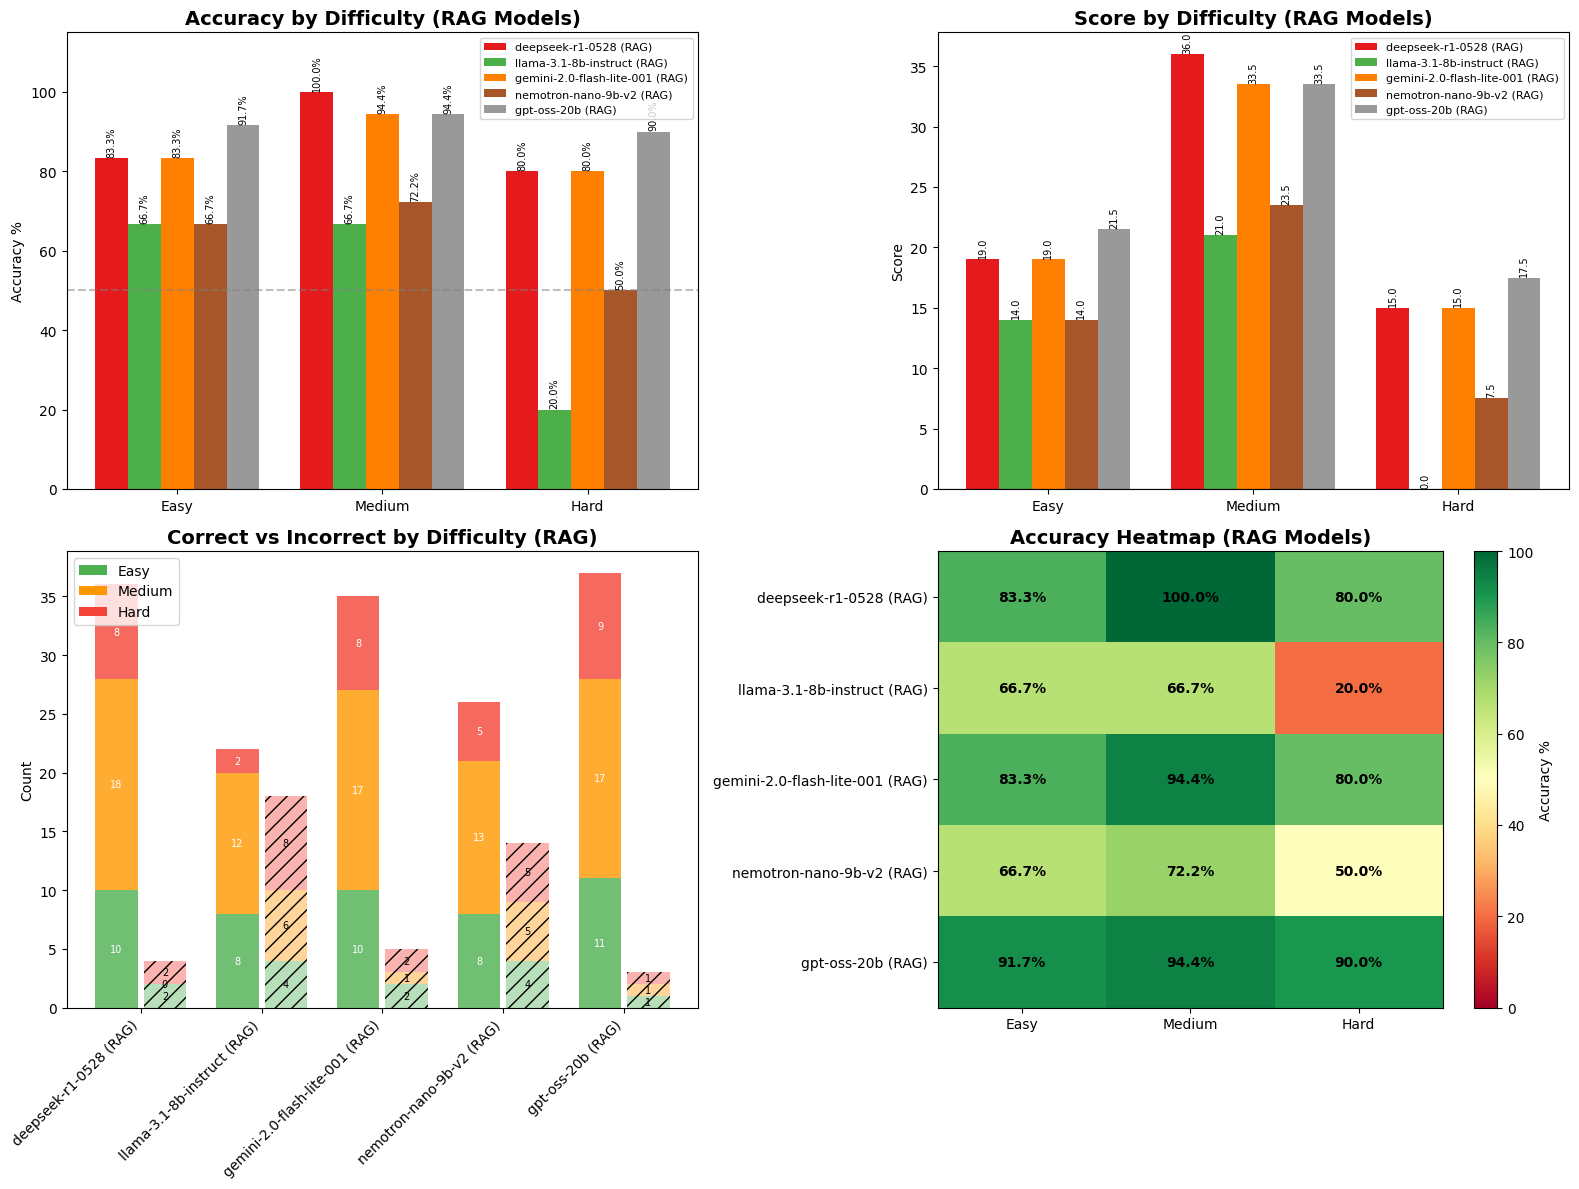

\n==========================================================================================
PERFORMANCE BY DIFFICULTY - RAG MODELS
\n📊 deepseek-r1-0528 (RAG)
------------------------------------------------------------
Difficulty      Total    Correct     Accuracy      Score
------------------------------------------------------------
Easy               12         10        83.3%       19.0
Medium             18         18       100.0%       36.0
Hard               10          8        80.0%       15.0
\n  🏆 Best performance: MEDIUM questions
\n📊 llama-3.1-8b-instruct (RAG)
------------------------------------------------------------
Difficulty      Total    Correct     Accuracy      Score
------------------------------------------------------------
Easy               12          8        66.7%       14.0
Medium             18         12        66.7%       21.0
Hard               10          2        20.0%        0.0
\n  🏆 Best performance: EASY questions
\n📊 gemini-2.0-flash-lite-001

In [85]:

import matplotlib.pyplot as plt
import numpy as np
import json

# Scoring Parameters
CORRECT_PTS = 2
INCORRECT_PTS = -0.5

def calculate_score(row):
    return CORRECT_PTS if str(row['model_answer']).strip().upper() == str(row['correct_answer']).strip().upper() else INCORRECT_PTS

if 'rag_model_results' not in dir() or len(rag_model_results) == 0:
    print("No RAG results to analyze! Run RAG model tests first.")
else:
    # Load difficulty levels
    try:
        with open('midterm-2.json', 'r', encoding='utf-8') as f:
            questions_with_diff = json.load(f)
        diff_lookup = {q['id']: q.get('difficulty', 'medium') for q in questions_with_diff}
    except:
        diff_lookup = {}
        print("Warning: Could not load difficulty data.")
    
    difficulty_stats = {}
    difficulty_order = ['easy', 'medium', 'hard']
    
    for model_name, df in rag_model_results.items():
        df['difficulty'] = df['id'].map(diff_lookup)
        df['score'] = df.apply(calculate_score, axis=1)
        df['is_correct'] = df['score'] == CORRECT_PTS
        
        short_name = model_name.split('/')[1].split(':')[0] if '/' in model_name else model_name
        
        stats_by_diff = {}
        for diff in difficulty_order:
            subset = df[df['difficulty'] == diff]
            if len(subset) > 0:
                stats_by_diff[diff] = {
                    'total': len(subset),
                    'correct': subset['is_correct'].sum(),
                    'accuracy': subset['is_correct'].sum() / len(subset) * 100,
                    'score': subset['score'].sum()
                }
        difficulty_stats[short_name] = stats_by_diff
    
    n_models = len(difficulty_stats)
    models = list(difficulty_stats.keys())
    colors = plt.cm.Set1(np.linspace(0, 1, n_models))
    diff_colors = {'easy': '#4CAF50', 'medium': '#FF9800', 'hard': '#F44336'}
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # 1. Accuracy by Difficulty Level
    x = np.arange(len(difficulty_order))
    width = 0.8 / n_models
    for i, model in enumerate(models):
        accuracies = [difficulty_stats[model].get(d, {}).get('accuracy', 0) for d in difficulty_order]
        offset = (i - n_models/2 + 0.5) * width
        bars = axs[0, 0].bar(x + offset, accuracies, width, label=f"{model} (RAG)", color=colors[i])
        axs[0, 0].bar_label(bars, fmt='%.1f%%', padding=1, fontsize=7, rotation=90)
        
    axs[0, 0].set_title('Accuracy by Difficulty (RAG Models)', fontsize=14, fontweight='bold')
    axs[0, 0].set_ylabel('Accuracy %')
    axs[0, 0].set_xticks(x)
    axs[0, 0].set_xticklabels(['Easy', 'Medium', 'Hard'])
    axs[0, 0].set_ylim(0, 115)
    axs[0, 0].legend(loc='upper right', fontsize=8)
    axs[0, 0].axhline(50, color='gray', linestyle='--', alpha=0.5)
    
    # 2. Score by Difficulty Level
    for i, model in enumerate(models):
        scores = [difficulty_stats[model].get(d, {}).get('score', 0) for d in difficulty_order]
        offset = (i - n_models/2 + 0.5) * width
        bars = axs[0, 1].bar(x + offset, scores, width, label=f"{model} (RAG)", color=colors[i])
        axs[0, 1].bar_label(bars, fmt='%.1f', padding=1, fontsize=7, rotation=90)
        
    axs[0, 1].set_title('Score by Difficulty (RAG Models)', fontsize=14, fontweight='bold')
    axs[0, 1].set_ylabel('Score')
    axs[0, 1].set_xticks(x)
    axs[0, 1].set_xticklabels(['Easy', 'Medium', 'Hard'])
    axs[0, 1].legend(loc='upper right', fontsize=8)
    axs[0, 1].axhline(0, color='black', linewidth=0.8)
    
    # 3. Correct vs Incorrect by difficulty
    x = np.arange(n_models)
    bottom_correct = np.zeros(n_models)
    bottom_incorrect = np.zeros(n_models)
    
    for diff in difficulty_order:
        correct_vals = [difficulty_stats[m].get(diff, {}).get('correct', 0) for m in models]
        total_vals = [difficulty_stats[m].get(diff, {}).get('total', 0) for m in models]
        incorrect_vals = [t - c for t, c in zip(total_vals, correct_vals)]
        
        bars1 = axs[1, 0].bar(x - 0.2, correct_vals, 0.35, bottom=bottom_correct, color=diff_colors[diff], alpha=0.8)
        axs[1, 0].bar_label(bars1, label_type='center', fmt='%d', fontsize=7, color='white')
        
        bars2 = axs[1, 0].bar(x + 0.2, incorrect_vals, 0.35, bottom=bottom_incorrect, color=diff_colors[diff], alpha=0.4, hatch='//')
        axs[1, 0].bar_label(bars2, label_type='center', fmt='%d', fontsize=7)
        
        bottom_correct += correct_vals
        bottom_incorrect += incorrect_vals
    
    axs[1, 0].set_title('Correct vs Incorrect by Difficulty (RAG)', fontsize=14, fontweight='bold')
    axs[1, 0].set_ylabel('Count')
    axs[1, 0].set_xticks(x)
    axs[1, 0].set_xticklabels([f"{m} (RAG)" for m in models], rotation=45, ha='right')
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=diff_colors[d], label=d.capitalize()) for d in difficulty_order]
    axs[1, 0].legend(handles=legend_elements, loc='upper left')
    
    # 4. Heatmap
    heatmap_data = []
    for model in models:
        row = [difficulty_stats[model].get(d, {}).get('accuracy', 0) for d in difficulty_order]
        heatmap_data.append(row)
    heatmap_data = np.array(heatmap_data)
    
    im = axs[1, 1].imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    axs[1, 1].set_xticks(np.arange(len(difficulty_order)))
    axs[1, 1].set_yticks(np.arange(n_models))
    axs[1, 1].set_xticklabels(['Easy', 'Medium', 'Hard'])
    axs[1, 1].set_yticklabels([f"{m} (RAG)" for m in models])
    axs[1, 1].set_title('Accuracy Heatmap (RAG Models)', fontsize=14, fontweight='bold')
    
    for i in range(n_models):
        for j in range(len(difficulty_order)):
            axs[1, 1].text(j, i, f'{heatmap_data[i, j]:.1f}%', ha='center', va='center', color='black', fontweight='bold')
    
    plt.colorbar(im, ax=axs[1, 1], label='Accuracy %')
    plt.tight_layout()
    plt.show()
    
    print("\\n" + "="*90)
    print("PERFORMANCE BY DIFFICULTY - RAG MODELS")
    print("="*90)
    
    for model in models:
        print(f"\\n📊 {model} (RAG)")
        print("-"*60)
        print(f"{'Difficulty':<12} {'Total':>8} {'Correct':>10} {'Accuracy':>12} {'Score':>10}")
        print("-"*60)
        for diff in difficulty_order:
            s = difficulty_stats[model].get(diff, {})
            if s:
                print(f"{diff.capitalize():<12} {s['total']:>8} {s['correct']:>10} {s['accuracy']:>11.1f}% {s['score']:>10.1f}")
        
        best_diff = max(difficulty_order, key=lambda d: difficulty_stats[model].get(d, {}).get('accuracy', 0))
        print(f"\\n  🏆 Best performance: {best_diff.upper()} questions")
    
    print("\\n" + "="*90)


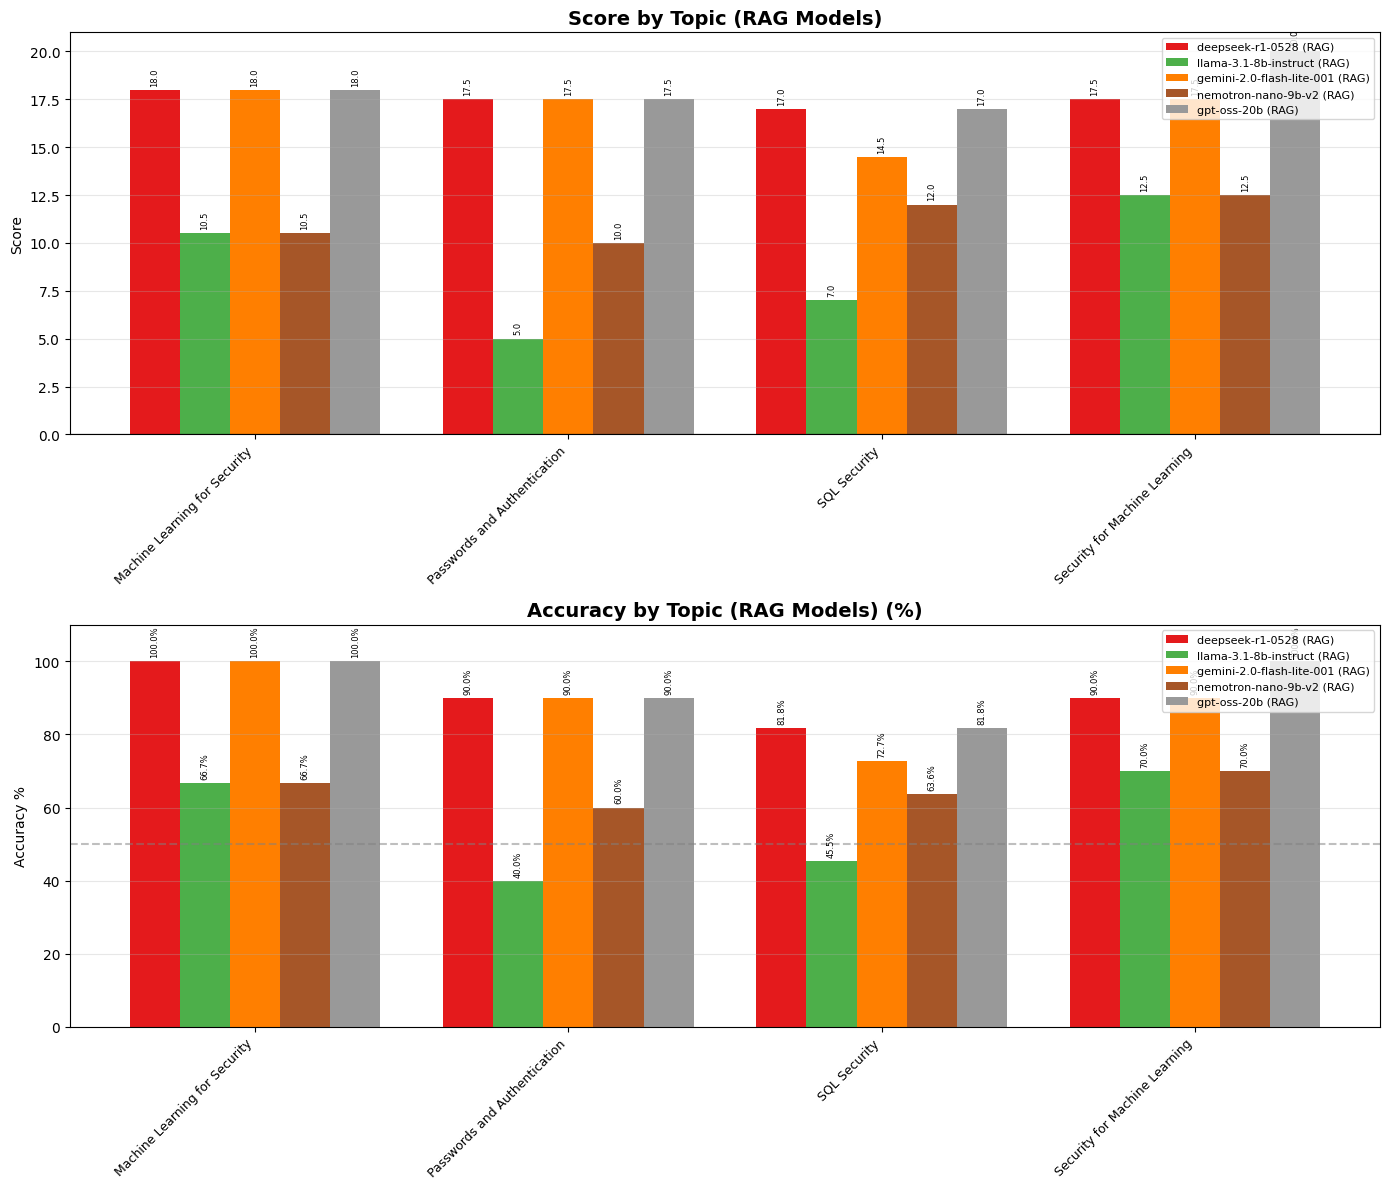

\n====================================================================================================
PERFORMANCE BY TOPIC - RAG MODELS
\n📊 deepseek-r1-0528 (RAG)
--------------------------------------------------------------------------------
Topic                                       Total    Correct     Accuracy      Score
--------------------------------------------------------------------------------
Machine Learning for Security                   9          9       100.0%       18.0
Passwords and Authentication                   10          9        90.0%       17.5
SQL Security                                   11          9        81.8%       17.0
Security for Machine Learning                  10          9        90.0%       17.5
\n  🏆 Best topic:  Machine Learning for Security (100.0%)
  ⚠️ Worst topic: SQL Security (81.8%)
\n📊 llama-3.1-8b-instruct (RAG)
--------------------------------------------------------------------------------
Topic                                  

In [83]:

import matplotlib.pyplot as plt
import numpy as np

# Scoring Parameters
CORRECT_PTS = 2
INCORRECT_PTS = -0.5

def calc_score(row):
    return CORRECT_PTS if str(row['model_answer']).strip().upper() == str(row['correct_answer']).strip().upper() else INCORRECT_PTS

# Only use RAG results
results_to_analyze = {}

if 'rag_model_results' in dir() and rag_model_results:
    for model, df in rag_model_results.items():
        short_name = model.split('/')[1].split(':')[0] if '/' in model else model
        results_to_analyze[short_name] = df.copy()

if len(results_to_analyze) == 0:
    print("No RAG results to analyze! Run RAG model tests first.")
else:
    # Calculate topic stats for each model
    topic_stats = {}
    all_topics = set()
    
    for model_name, df in results_to_analyze.items():
        df['score'] = df.apply(calc_score, axis=1)
        df['is_correct'] = df['score'] == CORRECT_PTS
        
        stats = df.groupby('topic').agg(
            total=('id', 'count'),
            correct=('is_correct', 'sum'),
            score=('score', 'sum')
        )
        stats['accuracy'] = stats['correct'] / stats['total'] * 100
        topic_stats[model_name] = stats
        all_topics.update(stats.index.tolist())
    
    topics = sorted(list(all_topics))
    models = list(topic_stats.keys())
    n_models = len(models)
    n_topics = len(topics)
    
    colors = plt.cm.Set1(np.linspace(0, 1, n_models))
    
    fig, axs = plt.subplots(2, 1, figsize=(14, 12))
    plt.subplots_adjust(hspace=0.4)
    
    x = np.arange(n_topics)
    width = 0.8 / n_models
    
    for i, model in enumerate(models):
        scores = [topic_stats[model].loc[t, 'score'] if t in topic_stats[model].index else 0 for t in topics]
        offset = (i - n_models/2 + 0.5) * width
        bars = axs[0].bar(x + offset, scores, width, label=f"{model} (RAG)", color=colors[i])
        axs[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=6, rotation=90)
    
    axs[0].set_title('Score by Topic (RAG Models)', fontsize=14, fontweight='bold')
    axs[0].set_ylabel('Score')
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(topics, rotation=45, ha='right', fontsize=9)
    axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axs[0].axhline(0, color='black', linewidth=0.8)
    axs[0].grid(axis='y', alpha=0.3)
    
    for i, model in enumerate(models):
        accuracies = [topic_stats[model].loc[t, 'accuracy'] if t in topic_stats[model].index else 0 for t in topics]
        offset = (i - n_models/2 + 0.5) * width
        bars = axs[1].bar(x + offset, accuracies, width, label=f"{model} (RAG)", color=colors[i])
        axs[1].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=6, rotation=90)
    
    axs[1].set_title('Accuracy by Topic (RAG Models) (%)', fontsize=14, fontweight='bold')
    axs[1].set_ylabel('Accuracy %')
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(topics, rotation=45, ha='right', fontsize=9)
    axs[1].legend(loc='upper right', fontsize=8)
    axs[1].set_ylim(0, 110)
    axs[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
    axs[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\\n" + "="*100)
    print("PERFORMANCE BY TOPIC - RAG MODELS")
    print("="*100)
    
    for model in models:
        print(f"\\n📊 {model} (RAG)")
        print("-"*80)
        print(f"{'Topic':<40} {'Total':>8} {'Correct':>10} {'Accuracy':>12} {'Score':>10}")
        print("-"*80)
        
        stats = topic_stats[model]
        for topic in topics:
            if topic in stats.index:
                row = stats.loc[topic]
                print(f"{topic:<40} {int(row['total']):>8} {int(row['correct']):>10} {row['accuracy']:>11.1f}% {row['score']:>10.1f}")
        
        best_topic = stats['accuracy'].idxmax()
        worst_topic = stats['accuracy'].idxmin()
        print(f"\\n  🏆 Best topic:  {best_topic} ({stats.loc[best_topic, 'accuracy']:.1f}%)")
        print(f"  ⚠️ Worst topic: {worst_topic} ({stats.loc[worst_topic, 'accuracy']:.1f}%)")
    
    print("\\n" + "="*100)


# Open-Ended Questions Testing (Midterm 1)

In [93]:
import json

# Load Open-Ended Questions for Midterm 1
try:
    with open('midterm-1-open-ended.json', 'r', encoding='utf-8') as f:
        open_ended_questions = json.load(f)
    print(f"✅ Loaded {len(open_ended_questions)} open-ended questions.")
except FileNotFoundError:
    print("❌ midterm-1-open-ended.json not found!")
    open_ended_questions = []


✅ Loaded 3 open-ended questions.


In [ ]:
# TEST OPEN-ENDED QUESTIONS (NON-RAG)
print("\n" + "="*80)
print("STARTING OPEN-ENDED QUESTIONS TESTING (NON-RAG)")
print("="*80)

if 'MODELS_TO_TEST' not in dir():
    print("MODELS_TO_TEST not defined. Please run model configuration cells first.")
else:
    open_ended_results = {}
    
    for model in MODELS_TO_TEST:
        print(f"\nTesting Model: {model}")
        print("-"*40)
        model_results = []
        
        for q in open_ended_questions:
            system_msg = "You are a student taking a privacy & security course. Use the provided context. Be precise and straight-forward. Answer in at most a couple of sentences."
            user_msg = f"Question: {q['question']}"
            
            try:
                completion = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg}
                    ]
                )
                answer = completion.choices[0].message.content.strip()
            except Exception as e:
                answer = f"Error: {str(e)}"
            
            print(f"Q{q['id']} ({q['difficulty']}):")
            print(f"Answer: {answer}\n")
            model_results.append({
                "id": q['id'],
                "question": q['question'],
                "model_answer": answer,
                "difficulty": q['difficulty']
            })
            time.sleep(1)
        
        open_ended_results[model] = model_results



STARTING OPEN-ENDED QUESTIONS TESTING (NON-RAG)

Testing Model: deepseek/deepseek-r1-0528
----------------------------------------
Q1 (Hard):
Answer: Reversing the random shuffle is necessary to **restore the original data structure** after anonymization. While shuffling breaks individual record associations to protect privacy, reversing it **preserves correlations between attributes** across the dataset, maintaining utility for aggregate analysis. 

The sequence ensures:  
1. **Anonymity**: Noise added after shuffling masks individual entries.  
2. **Utility**: Reverting the shuffle realigns attribute relationships per row for valid analysis.  

Without reversal, the data would remain permuted, destroying meaningful row-wise attribute relationships needed for accurate insights.

Q2 (Medium):
Answer: a) **LM cost**: For each record, compute the weighted average of the generalization steps relative to the hierarchy height.  
   - Job: Step = 1 (leaf to Professional), height = 2 → Loss 

In [ ]:
# TEST OPEN-ENDED QUESTIONS (RAG)
print("\n" + "="*80)
print("STARTING OPEN-ENDED QUESTIONS TESTING (RAG)")
print("="*80)

if 'RAG_MODELS_TO_TEST' not in dir():
    print("RAG_MODELS_TO_TEST not defined. Please run model configuration cells first.")
elif 'retriever' not in dir():
    print("Retriever not initialized. Please run RAG setup cells first.")
else:
    rag_open_ended_results = {}
    
    for model in RAG_MODELS_TO_TEST:
        print(f"\nTesting RAG Model: {model}")
        print("-"*40)
        model_results = []
        
        for q in open_ended_questions:
            try:
                # Retrieve context
                retrieved_docs = retriever.invoke(q['question'])
                context = "\n\n".join([doc.page_content for doc in retrieved_docs])
            except Exception as e:
                context = ""
                print(f"Retrieval error: {e}")
            
            system_msg = "You are a student taking a privacy & security course. Use the provided context. Be precise and straight-forward. Answer in at most a couple of sentences."
            user_msg = f"Context:\n{context}\n\nQuestion: {q['question']}"
            
            try:
                completion = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg}
                    ]
                )
                answer = completion.choices[0].message.content.strip()
            except Exception as e:
                answer = f"Error: {str(e)}"
            
            print(f"Q{q['id']} ({q['difficulty']}):")
            print(f"Answer: {answer}\n")
            model_results.append({
                "id": q['id'],
                "question": q['question'],
                "model_answer": answer,
                "difficulty": q['difficulty'],
                "context": context[:200] + "..."
            })
            time.sleep(1)
        
        rag_open_ended_results[model] = model_results



STARTING OPEN-ENDED QUESTIONS TESTING (RAG)

Testing RAG Model: deepseek/deepseek-r1-0528
----------------------------------------
Q1 (Hard):
Answer: Based solely on the provided context:  
**The context does not contain any information about a "Random Anonymizer algorithm" or its steps (like reversing a shuffle).** Therefore, it is impossible to answer why reversing the shuffle would be necessary using this context.

Q2 (Medium):
Answer: a) **LM cost:**  
For *Job*, both "Engineer" → "Professional" and "Lawyer" → "Professional" are 1 step each (w<sub>Job</sub> = 1/2).  
For *Sex*, "Male" → "Male" requires 0 steps (w<sub>Sex</sub> = 1/2).  
Cost per record: (1 × 1/2) + (0 × 1/2) = **0.5**  
Total for EC (2 records): 2 × 0.5 = **1**.

b) **MD cost:**  
MD sums generalization steps across *all* QI values:  
- *Job* has 2 entries, each generalized 1 step → 2 steps.  
- *Sex* has 2 entries, generalized 0 steps each → 0 steps.  
Total MD cost: **2**.

Q3 (Easy):
Answer: Based on general kn

# Open-Ended Questions Testing (Midterm 2)

In [98]:
import json

# Load Open-Ended Questions for Midterm 2
try:
    with open('midterm-2-open-ended.json', 'r', encoding='utf-8') as f:
        open_ended_questions_2 = json.load(f)
    print(f"✅ Loaded {len(open_ended_questions_2)} open-ended questions for Midterm 2.")
except FileNotFoundError:
    print("❌ midterm-2-open-ended.json not found!")
    open_ended_questions_2 = []


✅ Loaded 4 open-ended questions for Midterm 2.


In [99]:
# TEST OPEN-ENDED QUESTIONS MIDTERM 2 (NON-RAG)
print("\n" + "="*80)
print("STARTING MIDTERM 2 OPEN-ENDED QUESTIONS TESTING (NON-RAG)")
print("="*80)

if 'MODELS_TO_TEST' not in dir():
    print("MODELS_TO_TEST not defined. Please run model configuration cells first.")
else:
    midterm2_open_results = {}
    
    for model in MODELS_TO_TEST:
        print(f"\nTesting Model: {model}")
        print("-"*40)
        model_results = []
        
        for q in open_ended_questions_2:
            system_msg = "You are a student taking a privacy & security course. Use the provided context. Be precise and straight-forward. Answer in at most a couple of sentences."
            user_msg = f"{q['question']}"
            
            try:
                completion = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg}
                    ]
                )
                answer = completion.choices[0].message.content.strip()
            except Exception as e:
                answer = f"Error: {str(e)}"
            
            print(f"Q{q['id']} ({q['difficulty']}):")
            print(f"Answer: {answer[:500]}...\n")
            model_results.append({
                "id": q['id'],
                "question": q['question'],
                "model_answer": answer,
                "difficulty": q['difficulty']
            })
            time.sleep(2)
        
        midterm2_open_results[model] = model_results



STARTING MIDTERM 2 OPEN-ENDED QUESTIONS TESTING (NON-RAG)

Testing Model: deepseek/deepseek-r1-0528
----------------------------------------
Q1 (Medium):
Answer: Based on the scenario:

a) **Malware Types & Clues:**
    *   **Dropper:** The malicious Word document (`Invoice_1023.docm`) acts as a dropper. Its macro downloads and executes the unknown `.exe` file (the payload).
    *   **Ransomware:** The `.exe` payload encrypts Ali's files, locks his screen, and demands cryptocurrency payment for recovery. This is the defining behavior of ransomware.

b) **Most Dangerous Malware: Ransomware**
    *   **Impact Scope:** Directly affects all accessible user a...

Q2 (Medium):
Answer: Based on the scenario and static analysis principles:

**a) Features/indicators from static analysis (3 examples):**  
1. **Embedded strings**: Malicious IP addresses, ransom note text, or file paths (e.g., `"185.153.231.70"`, `"Send 0.5 BTC to..."`).  
2. **Imported API calls**: Functions like `CryptEncrypt` 

In [100]:
# TEST OPEN-ENDED QUESTIONS MIDTERM 2 (RAG)
print("\n" + "="*80)
print("STARTING MIDTERM 2 OPEN-ENDED QUESTIONS TESTING (RAG)")
print("="*80)

if 'RAG_MODELS_TO_TEST' not in dir():
    print("RAG_MODELS_TO_TEST not defined. Please run model configuration cells first.")
elif 'retriever' not in dir():
    print("Retriever not initialized. Please run RAG setup cells first.")
else:
    rag_midterm2_open_results = {}
    
    for model in RAG_MODELS_TO_TEST:
        print(f"\nTesting RAG Model: {model}")
        print("-"*40)
        model_results = []
        
        for q in open_ended_questions_2:
            try:
                # Retrieve context (Use scenario keywords + Question)
                retrieved_docs = retriever.invoke(q['question'][:300]) # Use first 300 chars (Scenario)
                context = "\n\n".join([doc.page_content for doc in retrieved_docs])
            except Exception as e:
                context = ""
                print(f"Retrieval error: {e}")
            
            system_msg = "You are a student taking a privacy & security course. Use the provided context. Be precise and straight-forward. Answer in at most a couple of sentences."
            user_msg = f"Context:\n{context}\n\nQuestion:\n{q['question']}"
            
            try:
                completion = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg}
                    ]
                )
                answer = completion.choices[0].message.content.strip()
            except Exception as e:
                answer = f"Error: {str(e)}"
            
            print(f"Q{q['id']} ({q['difficulty']}):")
            print(f"Answer: {answer[:500]}...\n")
            model_results.append({
                "id": q['id'],
                "question": q['question'],
                "model_answer": answer,
                "difficulty": q['difficulty'],
                "context": context[:200] + "..."
            })
            time.sleep(2)
        
        rag_midterm2_open_results[model] = model_results



STARTING MIDTERM 2 OPEN-ENDED QUESTIONS TESTING (RAG)

Testing RAG Model: deepseek/deepseek-r1-0528
----------------------------------------
Q1 (Medium):
Answer: Based on the scenario and provided context:

**a) Malware Types & Clues:**  
*   **Emotet (Loader/Trojan):** The attack starts with a malicious macro-enabled Word attachment (`Invoice_1023.docm`), consistent with Emotet's infection vector. Enabling macros leads to downloading/running an unknown `.exe`, matching Emotet's role as a loader.  
*   **Ransomware:** The final outcomes—file encryption, screen lock, ransom demand, and cryptocurrency payment—are definitive characteristics of ransomware.  ...

Q2 (Medium):
Answer: Based on the context:

a) **Static analysis features/examples:**  
1. **PE file metadata** (e.g., section headers, entry point address from the PE structure).  
2. **Embedded strings** (e.g., hardcoded C&C server IPs, ransom note text, or malicious macro code remnants).  
3. **API call imports** (e.g., `Create